In [1]:
# Compare raw outputs from two rAM3 experiments
import xarray as xr
from pathlib import Path
import iris
import matplotlib.pyplot as plt
import warnings
import numpy as np
warnings.filterwarnings('ignore',module='iris') 

In [2]:
# Check the original grib files for 20220226T00Z for potential temperature
GRIB_DIR = Path('/scratch/gb02/pag548/EC_GRIB_PARALLEL/')
grib = iris.load( GRIB_DIR / 'ec_grib_202202260000.t+000')

In [4]:
grib

[<iris 'Cube' of grib_skin_temperature / (K) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of UNKNOWN LOCAL PARAM 134.128 / (unknown) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of UNKNOWN LOCAL PARAM 139.128 / (unknown) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of UNKNOWN LOCAL PARAM 170.128 / (unknown) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of UNKNOWN LOCAL PARAM 183.128 / (unknown) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of UNKNOWN LOCAL PARAM 236.128 / (unknown) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of UNKNOWN LOCAL PARAM 39.128 / (unknown) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of UNKNOWN LOCAL PARAM 40.128 / (unknown) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of UNKNOWN LOCAL PARAM 41.128 / (unknown) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of UNKNOWN LOCAL PARAM 42.128 / (unknown) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of UNKNOWN LOCAL PARAM 133.128 / (unknown) (pressure: 37; latitude: 721; longitude: 1440)>,
<iris 'Cube' of UNKNOWN LOCAL PARAM 172.128 / (unknown) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of air_temperature / (K) (pressure: 37; latitude: 721; longitude: 1440)>,
<iris 'Cube' of geopotential / (m2 s-2) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of sea_ice_area_fraction / (1) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of sea_surface_temperature / (K) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of thickness_of_snowfall_amount / (m) (latitude: 721; longitude: 1440)>,
<iris 'Cube' of x_wind / (m s-1) (pressure: 37; latitude: 721; longitude: 1440)>,
<iris 'Cube' of y_wind / (m s-1) (pressure: 37; latitude: 721; longitude: 1440)>]

In [9]:
# Check some input files after first run of ec_recon_000
BASE_DIR=Path('/scratch/gb02/pag548/cylc-run/rCM3-test-UM-fcst/share/cycle/')
NEW_DIR=Path('/scratch/gb02/pag548/cylc-run/RNS_minimum_working_example/share/cycle/')
CYCLE = '20220226T0000Z'

In [6]:
# Load some select files after ec_um_recon finishes
files = ['ec_cb000_init']#, 'ec_cb006']
for file in files:
    base_cubes = iris.load( BASE_DIR / CYCLE / 'ec/um'/ file )
    new_cubes = iris.load ( NEW_DIR / CYCLE / 'ec/um'/ file ) 
    print (f'Analysing {file}\n')
    for i in range(len(base_cubes)):
        base_cube = base_cubes[i]
        new_cube = new_cubes[i]
        delta = base_cube.data.mean() - new_cube.data.mean()
        if np.abs(delta) > 0.0001:
            print (f'{base_cube.name()}, \t base mean = {base_cube.data.mean():.3f}, \t new_mean = {new_cube.data.mean():.3f}, Delta = {delta}')
    print (f'\n')

Analysing ec_cb000





In [7]:
base_t, = [ c for c in base_cubes if c.long_name=='virtual_potential_temperature' ]
ec_base_da = xr.DataArray.from_iris(base_t[0])

In [8]:
new_t, = [ c for c in new_cubes if c.long_name=='virtual_potential_temperature' ]
ec_new_da = xr.DataArray.from_iris(new_t[0])

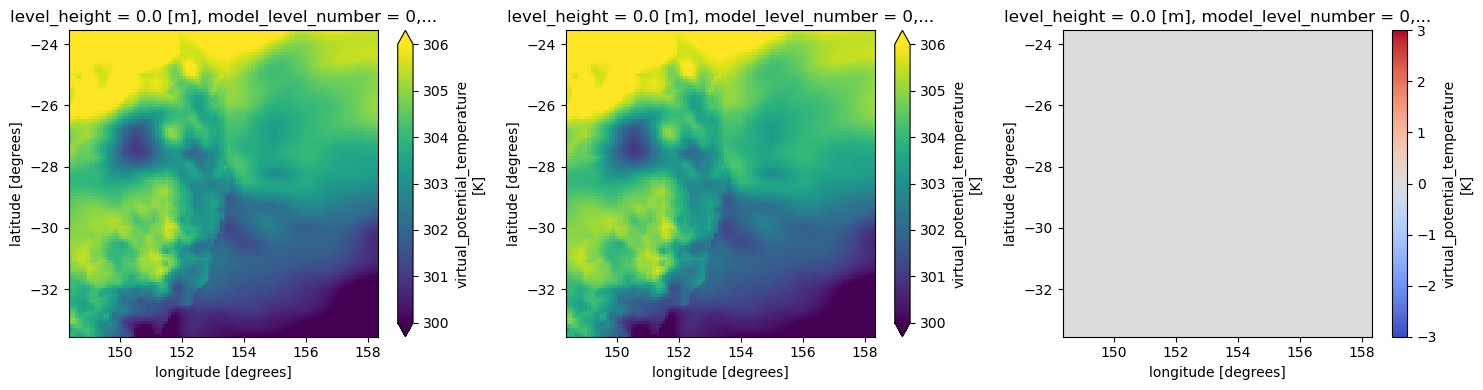

In [10]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
ec_base_da.plot(ax=ax[0],vmin=300,vmax=306)
ec_new_da.plot(ax=ax[1],vmin=300,vmax=306)
delta = ec_base_da-ec_new_da
delta.plot(ax=ax[2],cmap='coolwarm',vmin=-3,vmax=3)
plt.tight_layout()

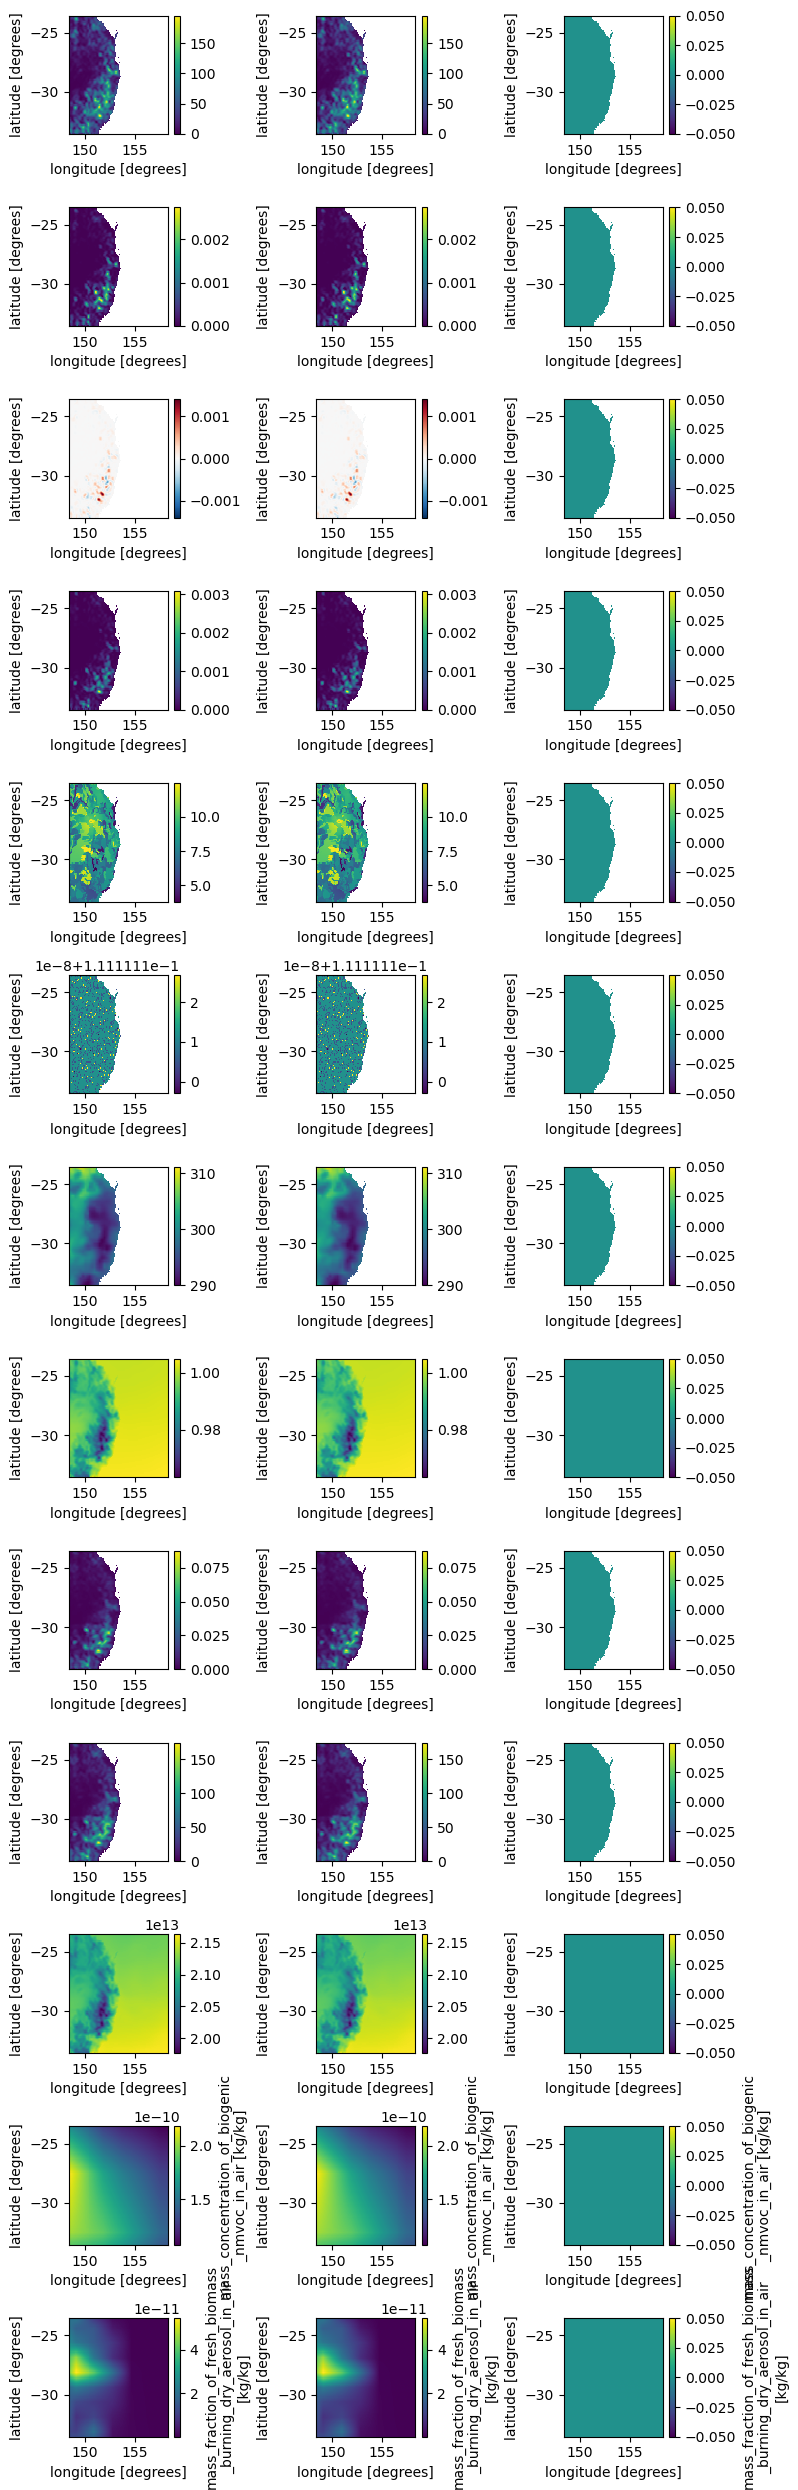

In [37]:
fig_rows=13
len_cubes= 116
fig,ax=plt.subplots(fig_rows,3,figsize=(8,25))
idx=0
for i,cube in enumerate(base_cubes):
    # Plot non-zero cubes
    base_cube_da = xr.DataArray.from_iris(base_cubes[i])
    new_cube_da = xr.DataArray.from_iris(new_cubes[i])

    if base_cube_da.mean() > 0.0:
        
        if 'pseudo_level' in base_cube_da.dims:
            base_cube_da = base_cube_da.mean(dim='pseudo_level')
            
        if 'pseudo_level' in new_cube_da.dims:
            new_cube_da = new_cube_da.mean(dim='pseudo_level')      

        if 'model_level_number' in base_cube_da.dims:
            base_cube_da = base_cube_da.mean(dim='model_level_number')
            
        if 'model_level_number' in new_cube_da.dims:
            new_cube_da = new_cube_da.mean(dim='model_level_number')     
        base_cube_da.plot(ax=ax[idx,0])
        new_cube_da.plot(ax=ax[idx,1])
        delta = base_cube_da - new_cube_da
        delta.plot(ax=ax[idx,2])
        idx+=1
    if idx > 12:
        break
[ a.set_title('') for a in ax.flatten() ]
plt.tight_layout()

In [13]:
# Repeat after nci_hres_eccb
# Load some select files after ec_um_recon finishes
files = ['ec_cb000_hres']#, 'ec_cb006']
for file in files:
    base_cubes_hres = iris.load( BASE_DIR / CYCLE / 'ec/um'/ file )
    new_cubes_hres = iris.load ( NEW_DIR / CYCLE / 'ec/um'/ file ) 
    print (f'Analysing {file}\n')
    for i in range(len(base_cubes_hres)):
        base_cube_hres = base_cubes_hres[i]
        new_cube_hres = new_cubes_hres[i]
        delta = base_cube_hres.data.mean() - new_cube_hres.data.mean()
        if np.abs(delta) > 0.0001:
            print (f'{base_cube_hres.name()}, \t base mean = {base_cube_hres.data.mean():.3f}, \t new_mean = {new_cube_hres.data.mean():.3f}, Delta = {delta}')
    print (f'\n')

Analysing ec_cb000_hres





In [14]:
base_t_hres, = [ c for c in base_cubes_hres if c.long_name=='virtual_potential_temperature' ]
ec_base_hres_da = xr.DataArray.from_iris(base_t_hres[0])

In [19]:
new_t_hres, = [ c for c in new_cubes_hres if c.long_name=='virtual_potential_temperature' ]
ec_new_hres_da = xr.DataArray.from_iris(new_t_hres[0])

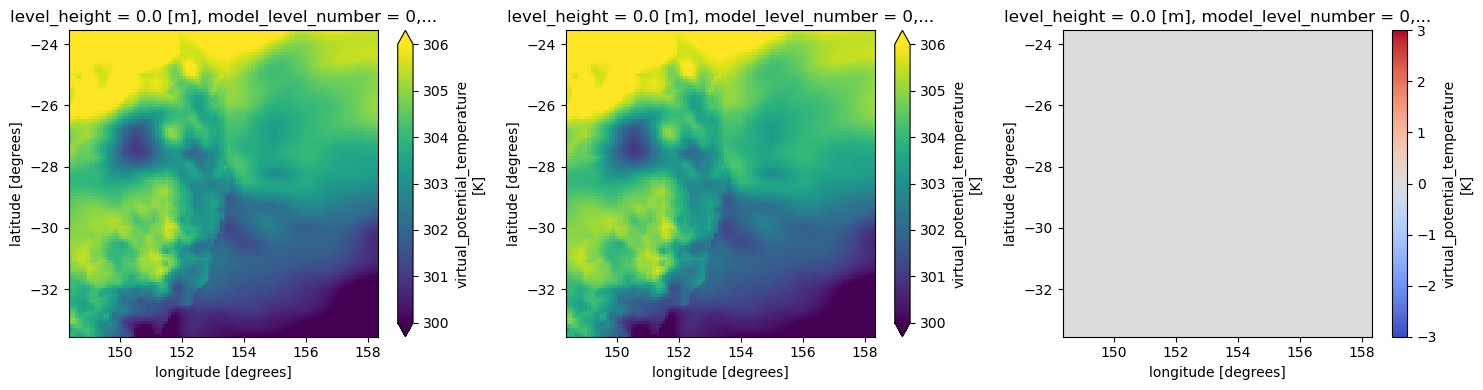

In [20]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
ec_base_hres_da.plot(ax=ax[0],vmin=300,vmax=306)
ec_new_hres_da.plot(ax=ax[1],vmin=300,vmax=306)
delta = ec_base_hres_da-ec_new_hres_da
delta.plot(ax=ax[2],cmap='coolwarm',vmin=-3,vmax=3)
plt.tight_layout()

In [ ]:
# Now examine the original GAL9 astart file

In [47]:
base_starts = iris.load ( BASE_DIR / CYCLE / 'Test_Ocean/test/GAL9/ics/GAL9_astart_init')
new_starts = iris.load ( NEW_DIR / CYCLE/ 'Test_Ocean/test/GAL9/ics/GAL9_astart_init')

In [48]:
for i in range(len(base_starts)):
    base = base_starts[i]
    new = new_starts[i]
    delta = base.data.mean() - new.data.mean()
    if np.abs(delta) > 0.0001:
        print (f'i={i}, {base.name()}, \t base mean = {base.data.mean():.3f}, \t new_mean = {new.data.mean():.3f}, Delta = {delta}')
print (f'\n')

In [49]:
# Investigate for virtual potential temperature
base_start_vpt, = [ c for c in base_starts if c.long_name=='virtual_potential_temperature' ]
new_start_vpt, = [ c for c in new_starts if c.long_name=='virtual_potential_temperature' ]

for k in range(base_start_vpt.shape[0]):
    base_start_vpt_slice = base_start_vpt[k]
    new_start_vpt_slice = new_start_vpt[k]
    delta = base_start_vpt_slice - new_start_vpt_slice
    if np.abs(delta.data.mean()) > 0.0001:
        print (f'k={k}, \t base mean = {base_start_vpt_slice.data.mean():.4f}, \t new_mean = {new_start_vpt_slice.data.mean():.4f}, Delta = {delta.data.mean()}')

In [50]:
k=0
base_start_vpt_slice_da = xr.DataArray.from_iris(base_start_vpt[k])
new_start_vpt_slice_da = xr.DataArray.from_iris(new_start_vpt[k])

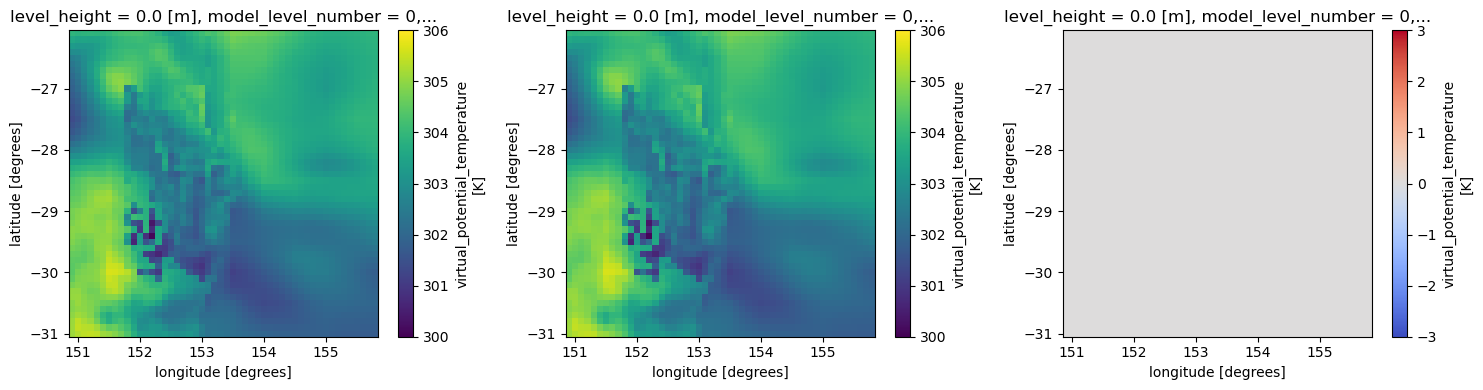

In [51]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
base_start_vpt_slice_da.plot(ax=ax[0],vmin=300,vmax=306)
new_start_vpt_slice_da.plot(ax=ax[1],vmin=300,vmax=306)
delta = base_start_vpt_slice_da-new_start_vpt_slice_da
delta.plot(ax=ax[2],cmap='coolwarm',vmin=-3,vmax=3)
plt.tight_layout()

In [52]:
#Compare this to the original EC grids at the same lat/limits
lat_bounds = [base_start_vpt_slice_da.latitude.data.min(),base_start_vpt_slice_da.latitude.data.max()]
lon_bounds = [base_start_vpt_slice_da.longitude.data.min(),base_start_vpt_slice_da.longitude.data.max()]

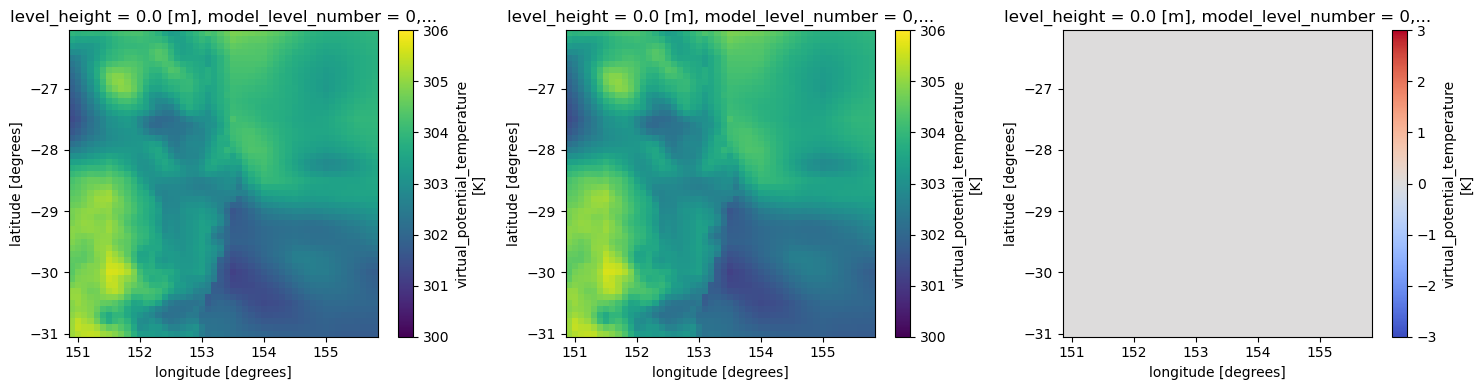

In [53]:
fig,ax=plt.subplots(1,3,figsize=(15,4))
ec_base_da.sel(latitude=slice(lat_bounds[0],lat_bounds[1]),
            longitude=slice(lon_bounds[0],lon_bounds[1])).plot(ax=ax[0],vmin=300,vmax=306)
ec_new_da.sel(latitude=slice(lat_bounds[0],lat_bounds[1]),
            longitude=slice(lon_bounds[0],lon_bounds[1])).plot(ax=ax[1],vmin=300,vmax=306)
delta = ec_base_da-ec_new_da
delta.sel(latitude=slice(lat_bounds[0],lat_bounds[1]),
          longitude=slice(lon_bounds[0],lon_bounds[1])).plot(ax=ax[2],cmap='coolwarm',vmin=-3,vmax=3)
plt.tight_layout()

In [59]:
# Repeat for hi-res GAL9 file
base_starts_hres = iris.load ( BASE_DIR / CYCLE / 'Test_Ocean/test/GAL9/ics/GAL9_astart_hres')
new_starts_hres = iris.load ( NEW_DIR / CYCLE/ 'Test_Ocean/test/GAL9/ics/GAL9_astart_hres')

for i in range(len(base_starts_hres)):
    base_hres = base_starts_hres[i]
    new_hres = new_starts_hres[i]
    delta = base_hres.data.mean() - new_hres.data.mean()
    if np.abs(delta) > 0.0001:
        print (f'i={i}, {base_hres.name()}, \t base mean = {base_hres.data.mean():.3f}, \t new_mean = {new_hres.data.mean():.3f}, Delta = {delta}')
print (f'\n')

In [60]:
# Replot virtual potential temperature
base_start_hres_vpt, = [ c for c in base_starts_hres if c.long_name=='virtual_potential_temperature' ]
new_start_hres_vpt, = [ c for c in new_starts_hres if c.long_name=='virtual_potential_temperature' ]

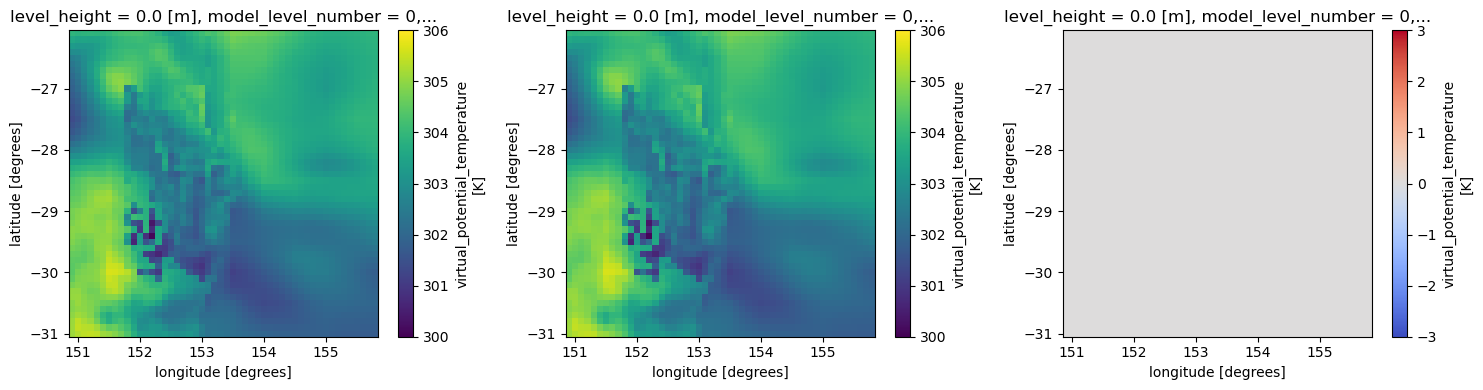

In [61]:
k=0
base_start_hres_vpt_slice_da = xr.DataArray.from_iris(base_start_hres_vpt[k])
new_start_hres_vpt_slice_da = xr.DataArray.from_iris(new_start_hres_vpt[k])

fig,ax=plt.subplots(1,3,figsize=(15,4))
base_start_hres_vpt_slice_da.plot(ax=ax[0],vmin=300,vmax=306)
new_start_hres_vpt_slice_da.plot(ax=ax[1],vmin=300,vmax=306)
delta = base_start_hres_vpt_slice_da-new_start_hres_vpt_slice_da
delta.plot(ax=ax[2],cmap='coolwarm',vmin=-3,vmax=3)
plt.tight_layout()

In [10]:
# Load some select files
files = ['umnsaa_pb000', 'umnsaa_pvera000']
for file in files:
    base_cubes = iris.load( BASE_DIR / CYCLE / 'Test_Ocean/test/GAL9/um/' / file )
    new_cubes = iris.load ( NEW_DIR / CYCLE / 'Test_Ocean/test/GAL9/um/' / file )
    print (f'Analysing {file}\n')
    for i in range(len(base_cubes)):
        base_cube = base_cubes[i]
        new_cube = new_cubes[i]
        delta = base_cube.data.mean() - new_cube.data.mean()
        print (f'{base_cube.name()}, \t base mean = {base_cube.data.mean():.3f}, \t new_mean = {new_cube.data.mean():.3f}, Delta = {delta}')
    print (f'\n')

Analysing umnsaa_pb000

air_pressure_at_sea_level, 	 base mean = 100873.750, 	 new_mean = 100873.750, Delta = 0.0
convective_rainfall_amount, 	 base mean = 0.018, 	 new_mean = 0.018, Delta = 0.0
stratiform_rainfall_amount, 	 base mean = 0.026, 	 new_mean = 0.026, Delta = 0.0
wind_speed_of_gust, 	 base mean = 12.979, 	 new_mean = 12.979, Delta = 0.0


Analysing umnsaa_pvera000

m01s01i202, 	 base mean = 288.268, 	 new_mean = 288.268, Delta = 0.0
Turbulent mixing height after boundary layer, 	 base mean = 559.404, 	 new_mean = 559.404, Delta = 0.0
m01s03i253, 	 base mean = 0.046, 	 new_mean = 0.046, Delta = 0.0
Cumulus capped boundary layer indicator, 	 base mean = 0.290, 	 new_mean = 0.290, Delta = 0.0
air_temperature, 	 base mean = 295.361, 	 new_mean = 295.361, Delta = 0.0
atmosphere_boundary_layer_thickness, 	 base mean = 465.994, 	 new_mean = 465.994, Delta = 0.0
dew_point_temperature, 	 base mean = 293.114, 	 new_mean = 293.114, Delta = 0.0
fog_area_fraction, 	 base mean = 0.038, 	

In [11]:
base_cube_da = xr.DataArray.from_iris(base_cube)
new_cube_da = xr.DataArray.from_iris(new_cube)

/jobfs/165096227.gadi-pbs/ipykernel_247133/1257074970.py:1: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  base_cube_da = xr.DataArray.from_iris(base_cube)
/jobfs/165096227.gadi-pbs/ipykernel_247133/1257074970.py:2: FutureWarning: In a future version, xarray will not decode the variable 'forecast_period' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, w

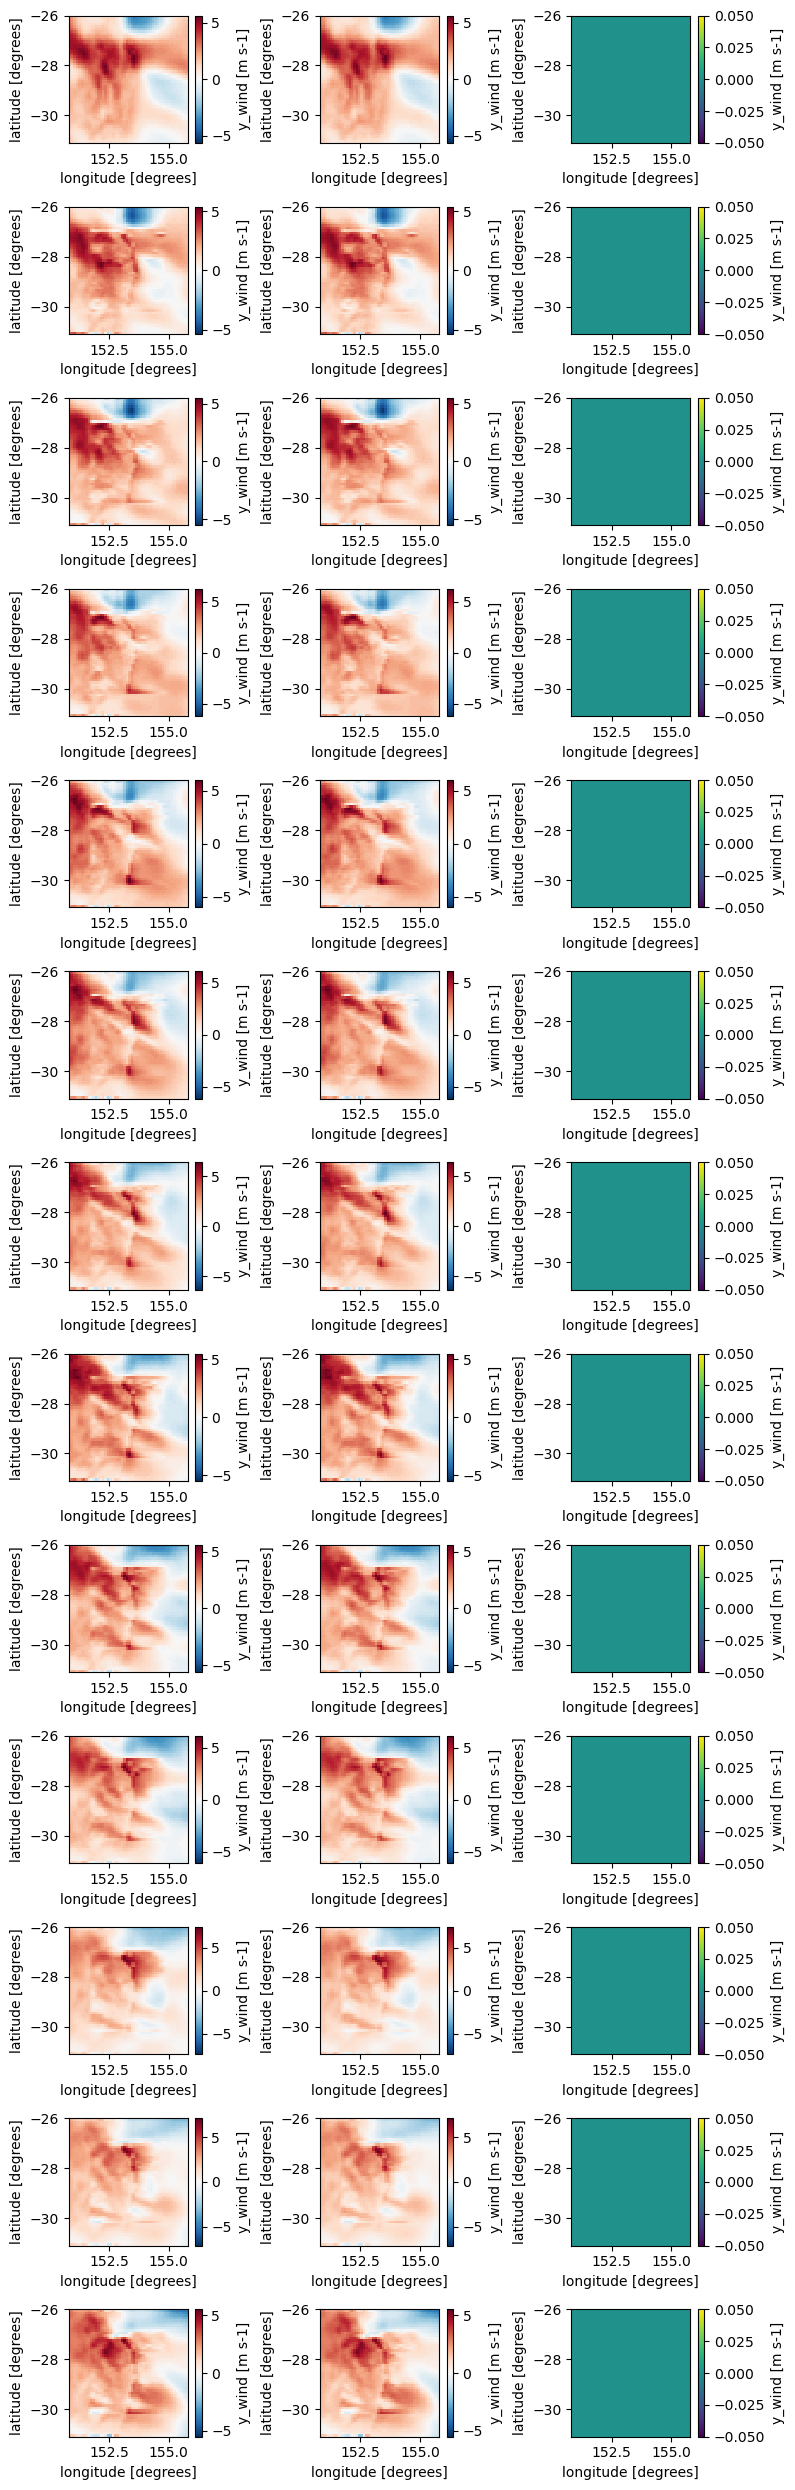

In [12]:
fig,ax=plt.subplots(13,3,figsize=(8,25))

for i,t  in enumerate(base_cube_da.time.data):
    base_cube_da.sel(time=t).plot(ax=ax[i,0])
    new_cube_da.sel(time=t).plot(ax=ax[i,1])
    delta = base_cube_da.sel(time=t) - new_cube_da.sel(time=t)
    delta.plot(ax=ax[i,2])

[ a.set_title('') for a in ax.flatten() ]
plt.tight_layout()